In [4]:
ML_DATA_TRAIN_PATH = './../data/final_data/ml_final_data_train.csv'
ML_DATA_VAL_PATH = './../data/final_data/ml_final_data_val.csv'
ML_DATA_TEST_PATH = './../data/final_data/ml_final_data_test.csv'
ML_WEIGHTS_PATH = './../utils/initial_pos_weights.json'
MODEL_PATH = './../stored_models/model_2_final_pos.h5'
import sqlite3
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.python.client import device_lib
import os
import sys
from collections import Counter
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization, Activation, Add, LeakyReLU, Concatenate, Multiply
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionResNetV2, VGG16, MobileNetV2
from tensorflow.keras.utils import to_categorical
from PIL import Image
import requests
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output as cls
from keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import statistics
import ast
import json
import statistics

import glob
import cv2
from PIL import Image
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

module_path = os.path.abspath(os.path.join('..', 'utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils2 import DataGenerator, plot_graph, bar_plot, two_bar_plot, StepwiseLogger

In [5]:
model = load_model(MODEL_PATH)

In [9]:
read_size = 524288
batch_size = 64
num_classes = 64
test_data_generator = DataGenerator(ML_DATA_TEST_PATH, read_size, batch_size, num_classes, 482813, initial_pos=True, final_pos=True)

In [10]:
model.evaluate(test_data_generator)
test_data_generator.current_read = None

7544/7544 [==============================] - 63s 7ms/step - loss: 3.3361 - initial_pos_loss: 1.3609 - final_pos_loss: 1.9751 - initial_pos_accuracy: 0.5060 - final_pos_accuracy: 0.4063


In [11]:
predictions = model.predict(test_data_generator)
test_data_generator.current_read = None

7544/7544 [==============================] - 57s 7ms/step


In [17]:
predictions[0] = np.argmax(predictions[0],axis=1)
predictions[1] = np.argmax(predictions[1],axis=1)

In [20]:
predictions[1]

array([39, 19, 54, ..., 44, 62, 40], dtype=int64)

In [23]:
group_predictions = np.unique(predictions[1], return_counts=True)
group_predictions_labels = decode_pos(group_predictions[0])

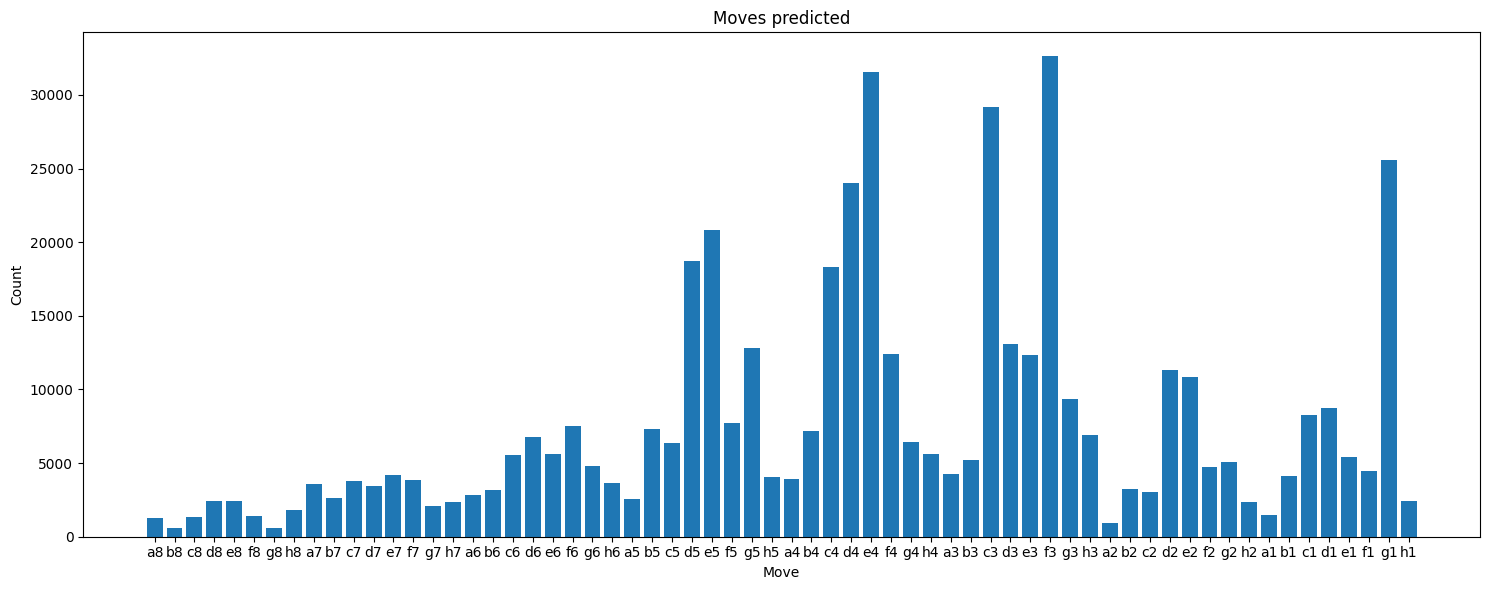

In [24]:
bar_plot(decode_pos(group_predictions[0]), group_predictions[1])

In [25]:
test_df = pd.read_csv(ML_DATA_TEST_PATH)
def sort_value_counts(value_counts):
    sorted_value_counts = []
    for row in ['8','7','6','5','4','3','2','1']:
        for column in ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']:
            sorted_value_counts.append(value_counts[column + row])
    return sorted_value_counts

In [26]:
sorted_value_counts = sort_value_counts(test_df['initial_pos'].value_counts())

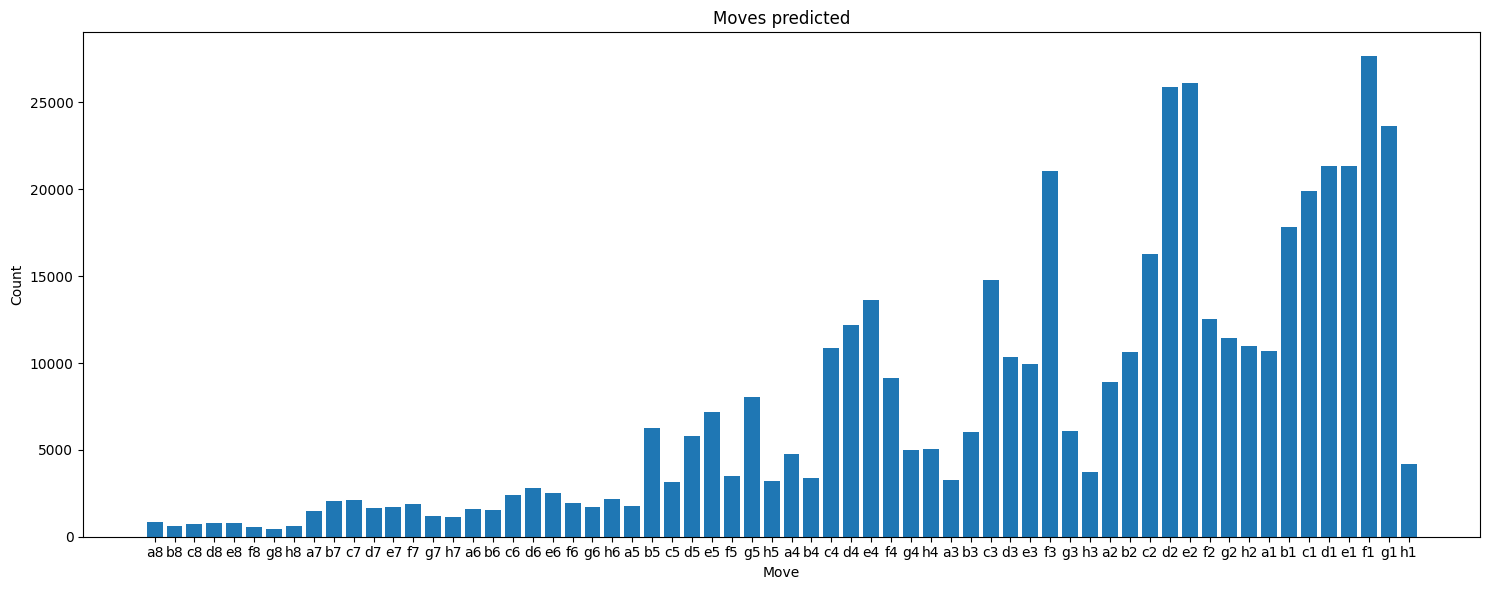

In [27]:
bar_plot(decode_pos(group_predictions[0]), sorted_value_counts)

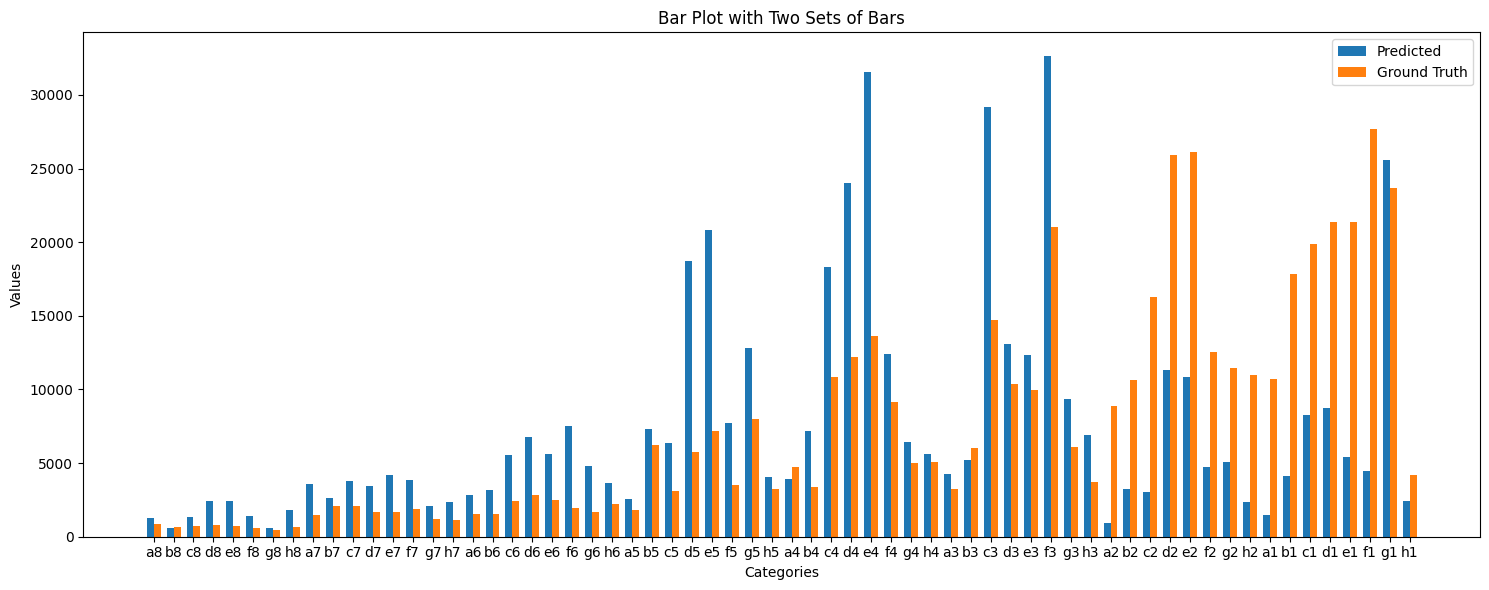

In [28]:
two_bar_plot(decode_pos(group_predictions[0]), group_predictions[1], sorted_value_counts)

In [32]:
print(classification_report(test_df['final_pos'], decode_pos(predictions[1])))

              precision    recall  f1-score   support

          a1       0.34      0.31      0.32      1580
          a2       0.47      0.30      0.37      1409
          a3       0.31      0.19      0.23      7061
          a4       0.37      0.20      0.25      7345
          a5       0.32      0.29      0.30      2861
          a6       0.34      0.40      0.36      2395
          a7       0.27      0.45      0.33      2151
          a8       0.36      0.31      0.33      1536
          b1       0.30      0.26      0.28      4804
          b2       0.45      0.42      0.43      3420
          b3       0.49      0.25      0.33     10246
          b4       0.35      0.35      0.35      7081
          b5       0.40      0.32      0.35      9122
          b6       0.34      0.38      0.36      2861
          b7       0.34      0.29      0.31      3046
          b8       0.40      0.21      0.27      1114
          c1       0.32      0.33      0.32      7885
          c2       0.38    

In [36]:
f1_score(test_df['final_pos'], decode_pos(predictions[1]), average='weighted')

0.39778734882916106

In [37]:
f1_scores = f1_score(test_df['final_pos'], decode_pos(predictions[1]), average=None)

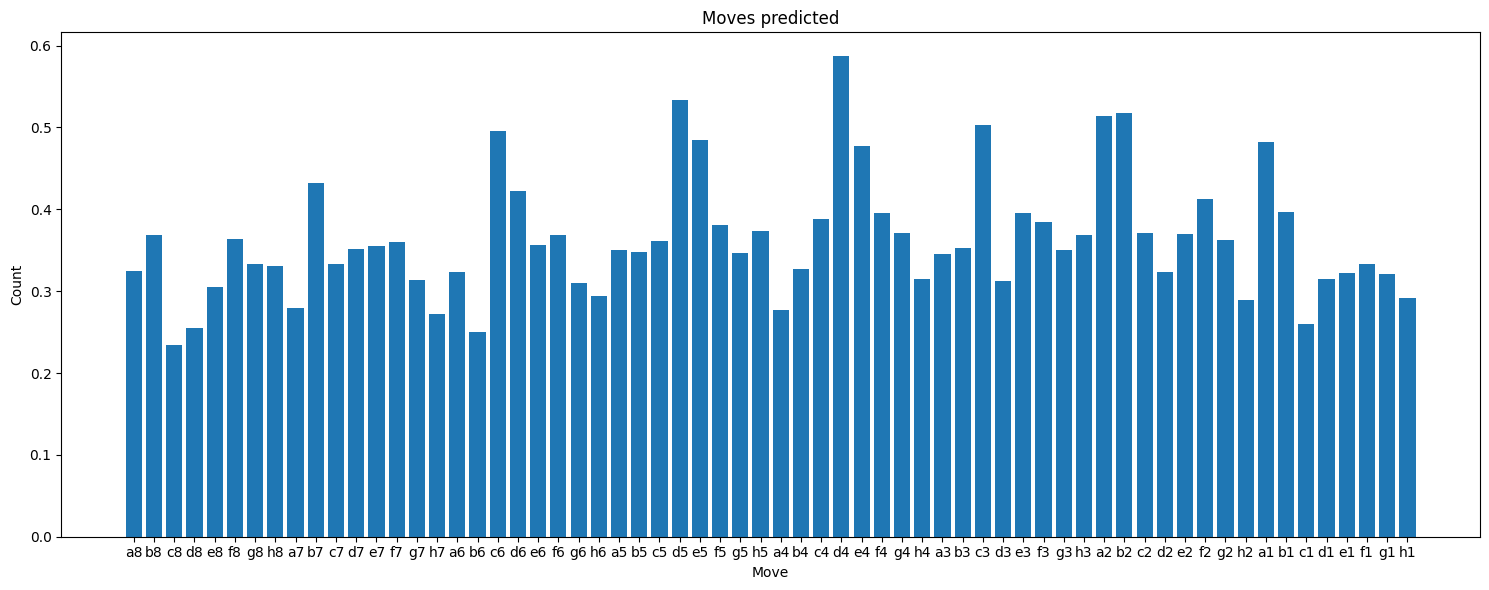

In [38]:
bar_plot(decode_pos(group_predictions[0]), f1_scores)